In [2]:
import os, sys

import xarray as xr
from cloudpathlib import AnyPath
import matplotlib.pyplot as plt
import scipy

# Local
curdir = os.getcwd()
print(curdir+"../data_processing")
sys.path.insert(0, curdir+"/../data_processing")
sys.path.insert(0, curdir+"/../visualization")
import ceres_ebaf
import ceres_ebaf_plotting

fig_path = AnyPath("../../Figs")
current_month_folder="23Aug"

merra_raw_location = AnyPath("/Users/mawa7160/dev/data/MERRA2/23Aug/Raw")
merra_output_location = AnyPath("/Users/mawa7160/dev/data/MERRA2/23Aug")
ceres_path = AnyPath("/Users/mawa7160/dev/data/CERES/EBAF/")

/Users/mawa7160/Library/CloudStorage/OneDrive-UCB-O365/Documents/GitHub/Hemispheric-Albedo-Project/Albedo_project/Notebooks../data_processing
/Users/mawa7160/Library/CloudStorage/OneDrive-UCB-O365/Documents/GitHub/Hemispheric-Albedo-Project/Albedo_project/Notebooks../data_processing


In [5]:
run_length = 12
merra_data = xr.open_dataset(merra_output_location / "Merra2_monthly_01_00-06_23.nc")
merra_surface_temp = ceres_ebaf.create_hemisphere_data(merra_data["TLML"],running_length=run_length)
merra_surface_temp_diff = merra_surface_temp["nh"] - merra_surface_temp["sh"]

ebaf_4_2_file_path = ceres_path / current_month_folder / "CERES_EBAF-TOA_Ed4.2_Subset_200003-202305.nc"
ebaf_full_years = xr.open_dataset(ebaf_4_2_file_path)
shortwave_all_sky_4_2 = ceres_ebaf.create_hemisphere_data(ebaf_full_years["toa_sw_all_mon"], running_length=run_length)
all_sky_diff_4_2 = shortwave_all_sky_4_2["nh"]-shortwave_all_sky_4_2["sh"]

In [7]:
surface_temp_anom = merra_surface_temp_diff-merra_surface_temp_diff.mean()
all_sky_anom = all_sky_diff_4_2-all_sky_diff_4_2.mean()

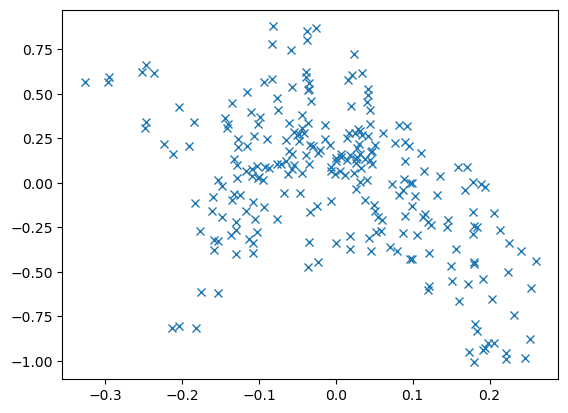

In [9]:
plt.plot(all_sky_anom, 'x')
scipy.stats.linregress(all_sky_anom)